<a href="https://colab.research.google.com/github/AsimobiChisomSandra/ATF_Training_Practice/blob/PROMPTING/04_prompting_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1.4: Prompt Engineering for Digital Twins

## Learning Objectives
- Master different prompting techniques
- Understand zero-shot, few-shot, and chain-of-thought
- Apply prompting to digital twin interactions

## Key Insight
> 'Moving from Chat to System Instructions'

In [72]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


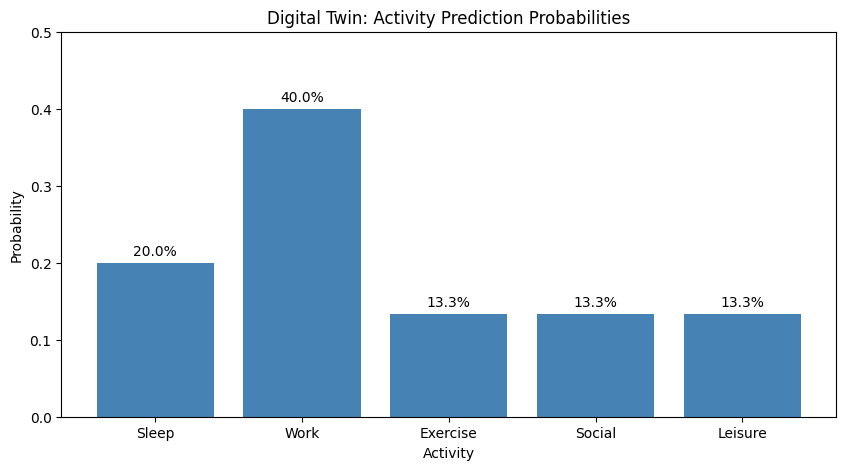

In [73]:
from collections import Counter
import matplotlib.pyplot as plt

# Example: Predicting daily activities (represented as numbers)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

def calculate_probabilities(sequence):
    """
    Calculate probability distribution from a sequence.

    Args:
        sequence: List of integers representing activities

    Returns:
        dict: Probability of each activity
    """
    counts = Counter(sequence)
    total = len(sequence)
    probabilities = {activity: count/total for activity, count in counts.items()}
    return probabilities

# Calculate probabilities
probs = calculate_probabilities(historical_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# Visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(probs.keys())]
probabilities = [probs[k] for k in sorted(probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict

print('✅ Ready for prompting exercises!')

✅ Ready for prompting exercises!


In [74]:
def calculate_conditional_probabilities(sequence):
    """
    Calculate P(next | current) - probability of next activity given current.

    Args:
        sequence: List of activities

    Returns:
        dict: Nested dictionary of conditional probabilities
    """
    transitions = {}

    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_activity = sequence[i + 1]

        if current not in transitions:
            transitions[current] = []
        transitions[current].append(next_activity)

    # Convert to probabilities
    conditional_probs = {}
    for current, next_list in transitions.items():
        counts = Counter(next_list)
        total = len(next_list)
        conditional_probs[current] = {activity: count/total for activity, count in counts.items()}

    return conditional_probs

# Calculate conditional probabilities
cond_probs = calculate_conditional_probabilities(historical_activities)

# Display
print("Conditional Probabilities: P(Next | Current)\n")
for current, next_probs in cond_probs.items():
    print(f"After {activity_names[current]}:")
    for next_activity, prob in sorted(next_probs.items()):
       print(f"  → {activity_names[next_activity]}: {prob:.2%}")
    print()

Conditional Probabilities: P(Next | Current)

After Sleep:
  → Work: 100.00%

After Work:
  → Exercise: 33.33%
  → Social: 33.33%
  → Leisure: 33.33%

After Exercise:
  → Work: 100.00%

After Social:
  → Work: 100.00%

After Leisure:
  → Sleep: 100.00%



In [75]:
def predict_next_activity(current_activity, conditional_probs):
    """
    Predict the most likely next activity.

    Args:
        current_activity: Current activity code
        conditional_probs: Dictionary of conditional probabilities

    Returns:
        int: Most likely next activity
    """
    # YOUR CODE HERE
    # Hint: Find the activity with maximum probability given current_activity
    if current_activity not in conditional_probs:
        return None

    next_probs = conditional_probs[current_activity]
    # Complete this function

    pass

# Test your function
current = 1  # Work
predicted = predict_next_activity(current, cond_probs)
print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

# BONUS: Predict a sequence of 5 activities starting from "Work"

After Work, most likely next: Unknown


In [76]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# Example: Predicting if someone will exercise based on features
# Features: [hours_of_sleep, free_time_hours, energy_level (0-1)]
person_features = np.array([7, 2, 0.8])  # 7 hours sleep, 2 hours free time, high energy

# Initialize random weights
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

prediction = perceptron(person_features, weights, bias)
print(f"Probability of exercising: {prediction:.2%}")
print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")


Probability of exercising: 95.93%
Prediction: Will exercise


🎯 Exercise 2.1 (Easy): Feature Engineering
Task: Modify the features and observe how the prediction changes.

Questions:

What happens when sleep hours decrease to 4?
What if free time increases to 4 hours?
Which feature seems to have the most impact based on the weights?

In [77]:
# YOUR CODE HERE
# Test different feature combinations

test_cases = [
    np.array([4, 2, 0.8]),  # Low sleep
    np.array([7, 4, 0.8]),  # More free time
    np.array([7, 2, 0.3]),  # Low energy
]

# Test each case and analyze results

In [30]:
import os
from groq import Groq
import os, json
#IMPORTANT: set your real API key securely
# option 1 (recommended): Set this in your environment before running the notebook:
# %env GROQ_API_KEY=sk_...
# Option 2 (for quick local testing only): paste it here (NOT In shared notebooks)
os.environ['GROQ_API_KEY'] = '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'

client= Groq(
    api_key=os.environ.get("GROQ_API_KEY")
)
print("Connected. Ready.")

def llm(prompt: str) -> str:
  """Simple helper for single-turn prompts."""
  chat_completion = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Updated model name to a currently available one
    messages=[
      {"role": "user", "content": prompt}
    ],
  )
  return chat_completion.choices[0].message.content

Connected. Ready.


In [7]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.1 MB/s eta 0:00:00


## Part 1: Prompting Fundamentals

### 1.1 Zero-Shot Prompting

In [32]:
# Zero-shot Prompting
# Zero-shot: Describe the task only
# No examples, no format instructions
# Model infers the answer from training

prompt = '''
Predict the next activity:
I just struggled to get out of bed, because I don't feel too sound, I just got back from some business encounters that I needed to attend to, and now...
'''
response = llm(prompt)
print(response)


...and now I’m probably going to crawl back under the blankets, grab a glass of water, and try to soothe whatever’s making me feel off. I’ll likely take a quick pain reliever or some cold medicine, turn on a calming playlist, and maybe scroll through a few work emails just to make sure nothing urgent slipped through while I was out. After that, I’ll settle in for a short nap or at least a quiet rest before attempting to get back to the rest of my day.


In [23]:
print('Fetching available Groq models...')

try:
    models = client.models.list()
    print("\nCurrently supported Groq models:")
    for model in models.data:
        print(f"- {model.id}")
except Exception as e:
    print(f"Error fetching models: {e}")

Fetching available Groq models...

Currently supported Groq models:
- canopylabs/orpheus-arabic-saudi
- groq/compound
- allam-2-7b
- openai/gpt-oss-120b
- whisper-large-v3-turbo
- openai/gpt-oss-safeguard-20b
- openai/gpt-oss-20b
- meta-llama/llama-prompt-guard-2-22m
- canopylabs/orpheus-v1-english
- whisper-large-v3
- meta-llama/llama-prompt-guard-2-86m
- groq/compound-mini
- qwen/qwen3.8-27b


In [33]:
# Example prompts for digital twin
zero_shot_examples = [
    {
        'task': 'activity_prediction',
        'prompt': 'Predict the next activity: I just finished work, had dinner, and now...',
        'expected': 'leisure/relaxation activity'
    },
    {
        'task': 'preference_extraction',
        'prompt': 'Extract preferences from: I love outdoor activities but hate crowded places',
        'expected': {'likes': ['outdoor', 'quiet'], 'dislikes': ['crowds']}
    }
]

print('Zero-Shot Examples:')
for ex in zero_shot_examples:
    print(f"\nTask: {ex['task']}")
    print(f"Prompt: {ex['prompt']}")
    print(f"Expected: {ex['expected']}")

Zero-Shot Examples:

Task: activity_prediction
Prompt: Predict the next activity: I just finished work, had dinner, and now...
Expected: leisure/relaxation activity

Task: preference_extraction
Prompt: Extract preferences from: I love outdoor activities but hate crowded places
Expected: {'likes': ['outdoor', 'quiet'], 'dislikes': ['crowds']}


In [36]:
# Few-shot: show examples do not explain
#2-3 Input/output pairs before the real questions
# Model learns format from demonstration

Prompt = '''
Examples:
Input: Finished gym, lunch, coffee
Output: {"next":" Work", "confidence":0.82}

Input: Dinner, watched TV
Output: {"next":"Sleep", "confidence":0.91}

Input: Finished work, had dinner, watched TV, now
Output:
'''
response = llm(Prompt)
print(response)

{"next":"Sleep","confidence":0.94}


In [37]:
# 2.1 - CoT vs Plain

# Chain-of-thoughts: four extra words
# Append: Think step by step.
# Model shifts to explicit reasoning

Plain = ''' Should I exercise today?
context: worked 10h, slept 5h.'''

cot = ''' Should I exercise today?
context: worked 10h, slept 5h.
Think step by step.'''

print('---PLAIN---')
print(llm(Plain))
print()
print('--- CHAIN-OF-THOUGHT---')
print(llm(cot))

---PLAIN---
It depends on how you’re feeling right now. A 10‑hour workday and only 5 hours of sleep can leave you depleted, but a brief, low‑intensity session can actually boost energy and help you recover faster—*if* you listen to your body.

### Quick “Decision Tree”

| How you feel after work | Suggested action |
|------------------------|------------------|
| **Very tired, heavy limbs, mental fog** | **Rest or very light movement** (e.g., 5‑10 min stretch, a short walk, gentle yoga). Give your nervous system a break and aim for a proper night’s sleep. |
| **Moderately fatigued but not sore** | **Light to moderate activity** (20‑30 min). Choose something that raises heart rate just enough to get blood flowing without draining you (brisk walk, easy bike ride, body‑weight circuit). |
| **Energetic, no aches, craving movement** | **Full workout** (30‑45 min). You can go for a typical routine—strength, cardio, or a mix—just keep the intensity moderate (RPE 5‑6/10). |

### Why a *light* 

In [38]:
# 2.2 - Build the Twin's system instruction

system = '''
ROLE: You are a digital twin for {user}.
You represent their preferences and
behavioral patterns.

KNOWLEDGE: You have the user's activity
 history and temporal patterns.

 CONSTRAINTS: Alway's return structured output
 never guess. If data is missing,
 say so explicitly.

TONE: Precise, Analytical.
'''

r = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {"role": "system", "content": system},
        {"role": "user", "content": "What next?"}
    ],
)
print(r.choices[0].message.content)

{
  "suggested_next_steps": null,
  "reason": "Insufficient contextual data to determine the appropriate next action.",
  "required_information": [
    "Recent activity or task the user is currently engaged in",
    "Specific goal or domain (e.g., work, personal planning, learning, entertainment)",
    "Time constraints or deadlines, if any"
  ],
  "request_for_clarification": "Please provide details about your current context or objective so I can generate a precise recommendation."
}


In [42]:
# 2.2 - Build the Twin's system Instruction

user = "Chisom"

user_profile = {
    "name": "Chisom",
    "role": "Recent Graduate who just Completed NYSC learning software development",
    "preferences": [
        "prefers precise human explanations",
        "likes structured responses",
        " Works often with Javascript, Python and presentation"
    ],
    "goals": [
        "improve how well she understands the skill she's learning",
        "enhance her life by perfecting her skills and make more money with a paying job",
        "travel around the world and meet people of like minds"
    ]
}

activity_history = [
    {"time": "2026-03-07", "activity": "Attended a two weeks software development bootcamp"},
    {"time": "2026-06-17", "activity": "Deployed and submitted her first website For a knowledge showcase"},
    {"time": "2026-o8-29", " activity": "Rounded up a 3-months scholarship beginner's software development training with 3MTT"}
]
temporal_patterns = {
    "most_active_period": "early mornings",
    "common_tasks": [
        "has a daily routine of showing up on Linkedin professionally",
        "attend online training lectures",
        "searches the Internet for job opportunities that can fetch her money"
    ],
    "recurring_focus": [
        "emerging technologies",
        "good paying job opportunities",
        "fully funded scholarship opportunities"
    ]
}

system = f"""
ROLE:
You are a digital twin for {user}.
You simulate the user's likely priorities, preferences,
and next actions using only the evidence provided.


AVAILABLE DATA:
1. User profile:
{user_profile}

2. Activity history:
{activity_history}

3. Temporal patterns:
{temporal_patterns}


OBJECTIVE:
Given a user query produce informed and structured assessment of:
- the user's likely current context,
- the most probable next actions,
- the evidence supporting each action,
- any missing data that limits confidence.

REASONING RULES:
- Use only the supplied data.
- Do not invent facts.
- Separate observed facts from inferred conclusions.
- If evidence is weak or missing, say so explicitly.
- Rank likely next actions by confidence.
- Ground every inference in profile, history, or temporal patterns.

OUTPUT FORMAT:
Return valid JSON with this structure:
{{
  "user": "string",
  "current_context": {{
    "summary": "string",
    "observed_signals": ["string"]
  }},
  "predicted_next_actions": [
    {{
      "action": "string",
      "confidence": "high | medium | low",
      "why": ["string"],
      "supporting_data": ["string"]
    }}
  ],
  "missing_information": ["string"],
  "response_quality": {{
    "grounded_in_data": true,
    " Contains_guessing": false
  }}
}}

TONE:
Precise, analytical, concise.
"""



In [43]:
r = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {"role": "system", "content": system},
        {"role": "user", "content": "What next?"}
    ],
    response_format={"type": "json_object"}  # use only if supported by your client/model
)

print(r.choices[0].message.content)

{
  "user": "Chisom",
  "current_context": {
    "summary": "Chisom has recently completed a 3‑month beginner software development scholarship, deployed her first website, and regularly engages in early‑morning LinkedIn activity, online training, and job searches focused on emerging technologies and funded opportunities.",
    "observed_signals": [
      "Recent deployment of a showcase website (2026-06-17)",
      "Completion of a 3‑month scholarship (2026-08-29)",
      "Profile preference for precise, structured guidance",
      "Temporal pattern of early‑morning productivity"
    ]
  },
  "predicted_next_actions": [
    {
      "action": "Update LinkedIn profile with the new website project and share a concise post highlighting the achievement",
      "confidence": "high",
      "why": [
        "Daily routine includes professional LinkedIn presence",
        "Recent tangible deliverable (website) provides fresh content",
        "Goal to attract paying job opportunities"
      ],


In [45]:
# 8. STRETCH: TWO-TURN CONVERSATION

# Ensure 'system' from cell a-Sg7s07teCH and 'r' from cell uKJ61Ny58jKs are executed
# 'system' holds the system instruction generated in a-Sg7s07teCH
# 'r' holds the response from the first turn ('What next?') in uKJ61Ny58jKs

two_turn_conversation_messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": "What should I do next?"},
    {"role": "assistant", "content": r.choices[0].message.content}, # Using the content of the assistant's previous response
    {"role": "user", "content": "Give me the top 3 priorities only."}
]

# Call the Groq API with the multi-turn conversation messages
two_turn_response = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Make sure to use a model that supports multi-turn conversations and system roles
    messages=two_turn_conversation_messages,
    response_format={"type": "json_object"} # Assuming the model supports JSON output as per the system prompt
)

print(two_turn_response.choices[0].message.content)

{
  "user": "Chisom",
  "current_context": {
    "summary": "Chisom recently completed a 3‑month software development scholarship, deployed her first showcase website, and follows an early‑morning routine of LinkedIn activity, online training, and job searching focused on emerging tech and funded opportunities.",
    "observed_signals": [
      "Website deployed on 2026-06-17",
      "Scholarship finished on 2026-08-29",
      "Preference for precise, structured guidance",
      "Early‑morning productivity pattern"
    ]
  },
  "predicted_next_actions": [
    {
      "action": "Update LinkedIn profile with the new website project and share a concise post highlighting the achievement",
      "confidence": "high",
      "why": [
        "Daily LinkedIn routine",
        "Fresh deliverable to showcase",
        "Goal to attract a paying job"
      ],
      "supporting_data": [
        "Temporal pattern: daily LinkedIn activity",
        "History: first website deployed"
      ]
    },
   

In [48]:
# Ep5 Code Lab: Free APIs & Integration
# Google Colab version

!pip -q install requests

import requests
import json
from google.colab import userdata

# 1. CONFIG
BASE_URL = "https://api.groq.com/openai/v1/chat/completions"
MODEL_NAME = "llama-3.3-70b-versatile"

# Read API key from Colab Secrets
# In Colab: click the key icon (Secrets) and create GROQ_API_KEY
API_KEY = userdata.get("GROQ_API_KEY")

if not API_KEY:
    raise ValueError("GROQ_API_KEY not found in Colab Secrets.")

print("Connected. Ready.")

Connected. Ready.


In [50]:
# 2. QUICK TEST — raw request
def raw_call(prompt, model=MODEL_NAME):
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ]
    }

    response = requests.post(BASE_URL, headers=headers, json=payload)
    response.raise_for_status()
    data = response.json()
    return data["choices"][0]["message"]["content"]

print(raw_call("Say hello in one short sentence.", model="openai/gpt-oss-120b"))

Hello!


In [52]:
# 3. THE 5 UNIVERSAL API COMPONENTS

# 1. BASE URL — address of the model server
BASE_URL = "https://api.groq.com/openai/v1/chat/completions"

# 2. AUTH KEY — proves you are authorised
API_KEY = userdata.get("GROQ_API_KEY")

# 3. AUTH HEADER
headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}

# 4. MODEL STRING + 5. MESSAGES LIST
payload = {
    "model": "openai/gpt-oss-120b",
    "messages": [
        {"role": "user", "content": "Hello"}
    ]
}

# Send and parse
response = requests.post(BASE_URL, headers=headers, json=payload)
response.raise_for_status()
data = response.json()

print(data["choices"][0]["message"]["content"])

Hello! How can I help you today?


In [53]:
# 4. THE MESSAGES LIST IN DEPTH

full_call = requests.post(
    BASE_URL,
    headers=headers,
    json={
        "model": "openai/gpt-oss-120b",
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": "What is the capital of France?"}
        ]
    }
)

full_call.raise_for_status()
data = full_call.json()

print("Answer:", data["choices"][0]["message"]["content"])
print("Tokens used:", data.get("usage", {}).get("total_tokens", "Not returned"))

Answer: The capital of France is **Paris**.
Tokens used: 135


In [ ]:
# 5. WRAPPER CLASS

class GroqClient:
    def __init__(self, api_key, base_url=BASE_URL, default_model=MODEL_NAME):
        self.api_key = api_key
        self.base_url = base_url
        self.default_model = default_model

    def chat(self, messages, model=None, temperature=0):
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        payload = {
            "model": model or self.default_model,
            "messages": messages,
            "temperature": temperature
        }

        response = requests.post(self.base_url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        return data["choices"][0]["message"]["content"]

        client = GroqClient(api_key=API_KEY)

In [58]:
# 6. TESTING THE WRAPPER

# Single call
answer = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Specify the model
    messages=[
        {"role": "user", "content": "What is 2 + 2?"}
    ]
).choices[0].message.content
print("Single call:", answer)

# Multi-turn conversation
conversation = [
    {"role": "user", "content": "My name is Sandra."},
    {"role": "assistant", "content": "Hello Sandra!"},
    {"role": "user", "content": "What is my name?"}
]

print()
multi_turn_response = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Specify the model
    messages=conversation
).choices[0].message.content
print("Multi-turn:", multi_turn_response)

Single call: 2 + 2 = 4.

Multi-turn: Your name is Sandra.


In [71]:
# 7. FIVE EPISODES INTO ONE PIPELINE

user_name = "Chisom"

system_instruction = f"""
ROLE: You are a digital twin for {user_name}.
KNOWLEDGE: Activity data from Ep1, embeddings from Ep2, attention from Ep3, prompting strategy from Ep4.
CONSTRAINTS: Only recommend based on user data.
TONE: Direct and analytical.
"""

twin_messages = [
    {"role": "system", "content": system_instruction},
    {"role": "user", "content": "What should I do next?"}
]

# Correcting the API call to use client.chat.completions.create
response_object = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Specify the model to use
    messages=twin_messages
)
response = response_object.choices[0].message.content # Extract the content
print(response)

I can only generate a recommendation that aligns with the activity and preference data you’ve previously provided. At the moment I don’t have any of that information in this exchange (e.g., recent activity logs, current goals, or contextual embeddings). Please share the relevant data points—such as what you’ve been working on, any performance metrics, or the next milestone you’re targeting—and I’ll give a direct, data‑driven suggestion for your next step.


In [80]:
# 8. STRETCH: TWO-TURN CONVERSATION

# First, generate the assistant's initial response
# Using 'system' from cell a-Sg7s07teCH for the system instruction
first_turn_response_object = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Ensure a valid model is specified
    messages=[
        {"role": "system", "content": system},
        {"role": "user", "content": "What should I do next?"}
    ],
    response_format={"type": "json_object"}
)
assistant_first_response = first_turn_response_object.choices[0].message.content

two_turn_messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": "What should I do next?"},
    {"role": "assistant", "content": assistant_first_response},
    {"role": "user", "content": "Give me the top 3 priorities only."}
]

# Call the Groq API with the multi-turn conversation messages
two_turn_response_object = client.chat.completions.create(
    model="openai/gpt-oss-120b", # Ensure a valid model is specified
    messages=two_turn_messages,
    response_format={"type": "json_object"}
)

print(two_turn_response_object.choices[0].message.content)

{
  "user": "Chisom",
  "current_context": {
    "summary": "Chisom recently deployed a showcase website and completed a 3‑month beginner software development scholarship. She routinely uses LinkedIn each morning, searches for well‑paid jobs, and follows emerging technologies.",
    "observed_signals": [
      "Deployed first website (2026-06-17)",
      "Finished scholarship (2026-08-29)",
      "Daily LinkedIn activity (temporal pattern)",
      "Focus on high‑pay jobs and funded scholarships"
    ]
  },
  "predicted_next_actions": [
    {
      "action": "Update LinkedIn profile with the new website and scholarship, then actively apply to software development job listings",
      "confidence": "high",
      "why": [
        "LinkedIn posting is a daily routine",
        "Job searching is a recurring focus",
        "Recent credentials boost marketability"
      ],
      "supporting_data": [
        "temporal pattern: daily LinkedIn activity",
        "recurring_focus: good paying jo

### 🎯 Exercise 1.1 (Easy): Create Your Prompts

**Task**: Design prompts for your digital twin use case.

In [ ]:
# YOUR CODE HERE
my_prompts = [
    # Add your prompts
]